# Life Expectancy Analysis
***
Visualization project exploring life expectancy from year 2000-2015 for 193 countries. For the analysis, we will consider factors such as alcohol, medical conditions, and BMI.

## Problem Statement
- How life expectancy has changed over the years
- Does Life Expectancy has positive or negative correlation with eating habits, lifestyle, exercise, smoking, drinking alcohol etc.
- What is the impact of schooling on the lifespan of humans?
- Do densely populated countries tend to have lower life expectancy?

In [31]:
import numpy as np 
import pandas as pd

df = pd.read_csv("data\\life_expectancy_data.csv")
print("Shape: ", df.shape)
print(df.head())

Shape:  (2938, 22)
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Po

***
### 1. Structure & dtypes

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

***
### 2. Missing values

In [33]:
missing = df.isnull().sum()
print("Number of missing values: ")
print(" ")
print(missing)

Number of missing values: 
 
Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


In [34]:
clear = df.dropna()
print("Data after removing missing values: ")
print(" ")
print(clear)

Data after removing missing values: 
 
          Country  Year      Status  Life expectancy   Adult Mortality  \
0     Afghanistan  2015  Developing              65.0            263.0   
1     Afghanistan  2014  Developing              59.9            271.0   
2     Afghanistan  2013  Developing              59.9            268.0   
3     Afghanistan  2012  Developing              59.5            272.0   
4     Afghanistan  2011  Developing              59.2            275.0   
...           ...   ...         ...               ...              ...   
2933     Zimbabwe  2004  Developing              44.3            723.0   
2934     Zimbabwe  2003  Developing              44.5            715.0   
2935     Zimbabwe  2002  Developing              44.8             73.0   
2936     Zimbabwe  2001  Developing              45.3            686.0   
2937     Zimbabwe  2000  Developing              46.0            665.0   

      infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measl

***
### 3. Numeric distributions

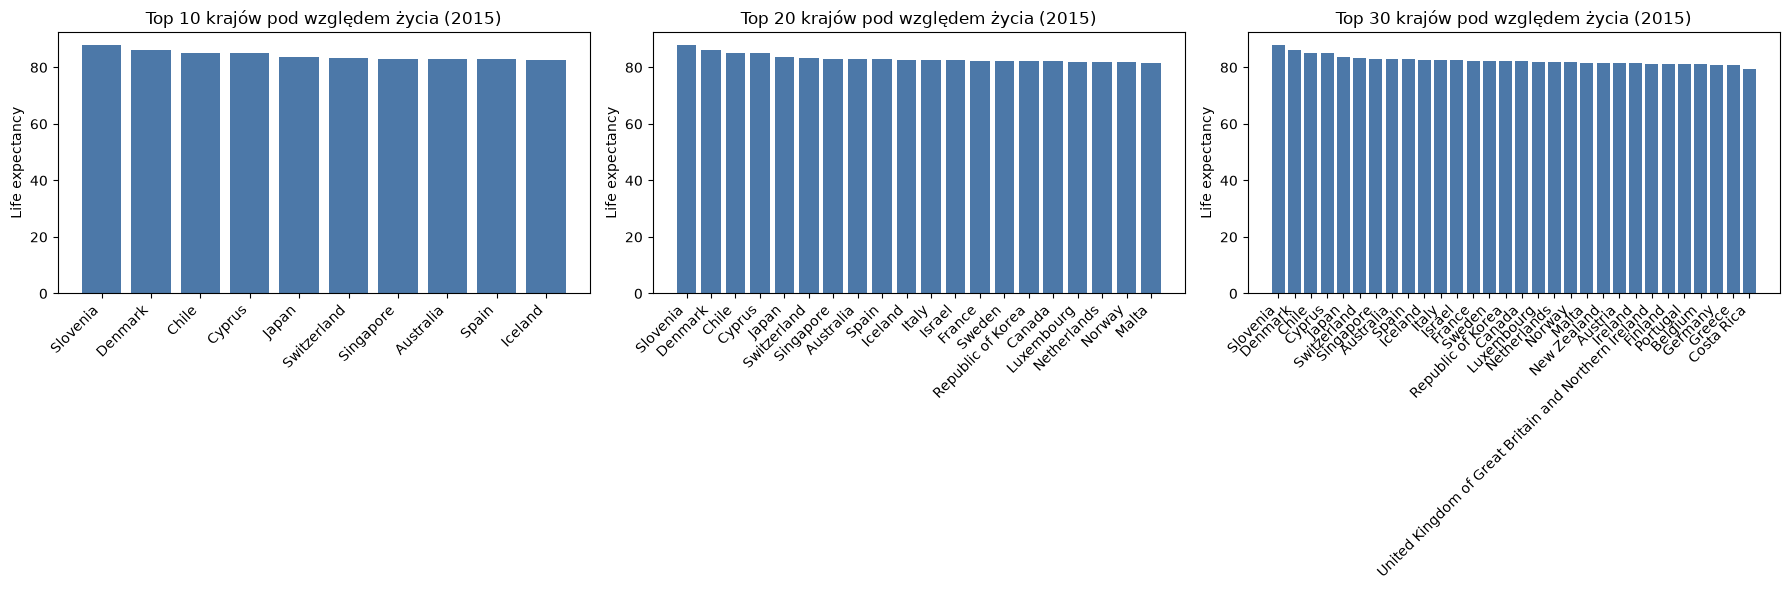

In [ ]:
import matplotlib.pyplot as plt

# Wybierz dane z 2015 roku i usuń brakujące wartości dla life expectancy
country_data = df[df["Year"] == 2015].copy()
country_data = country_data.dropna(subset=["Life expectancy "])

# Top 10 najlepszych i top 10 najgorszych krajów
best = country_data.sort_values("Life expectancy ", ascending=False).head(10)
worst = country_data.sort_values("Life expectancy ", ascending=True).head(10)

# Przygotuj dwa wykresy słupkowe
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(best["Country"], best["Life expectancy "], color="#4C78A8")
axes[0].set_title("Top 10 najlepszych krajów (2015)")
axes[0].set_ylabel("Life expectancy")
axes[0].tick_params(axis="x", rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

axes[1].bar(worst["Country"], worst["Life expectancy "], color="#E45756")
axes[1].set_title("Top 10 najgorszych krajów (2015)")
axes[1].set_ylabel("Life expectancy")
axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.tight_layout()
plt.show()

In [36]:

drop = df.drop_duplicates(subset=["Country"])
print("Data only for year 2015")
print(" ")
print(drop.head(15))


Data only for year 2015
 
                 Country  Year      Status  Life expectancy   Adult Mortality  \
0            Afghanistan  2015  Developing              65.0            263.0   
16               Albania  2015  Developing              77.8             74.0   
32               Algeria  2015  Developing              75.6             19.0   
48                Angola  2015  Developing              52.4            335.0   
64   Antigua and Barbuda  2015  Developing              76.4             13.0   
80             Argentina  2015  Developing              76.3            116.0   
96               Armenia  2015  Developing              74.8            118.0   
112            Australia  2015   Developed              82.8             59.0   
128              Austria  2015   Developed              81.5             65.0   
144           Azerbaijan  2015  Developing              72.7            118.0   
160              Bahamas  2015  Developing              76.1            147.0   
17